# Exploratory Data Analysis on Superstore Sales Dataset

## Objective

The objective of this project is to analyze sales trends, profitability, customer segments, and regional performance using data analytics techniques. The project aims to uncover meaningful business insights through data cleaning, visualization, and exploratory analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Visualization style
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
df = pd.read_csv("../dataset/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Rows and Columns:
(9994, 21)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

# Dataset Overview

The Superstore Sales Dataset contains sales transactions from a retail business. The dataset includes information about products, customers, sales, profit, regions, and customer segments.

### Dataset Summary

- Total Records: 9,994
- Total Features: 21
- Missing Values: 0
- Duplicate Records: 0

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


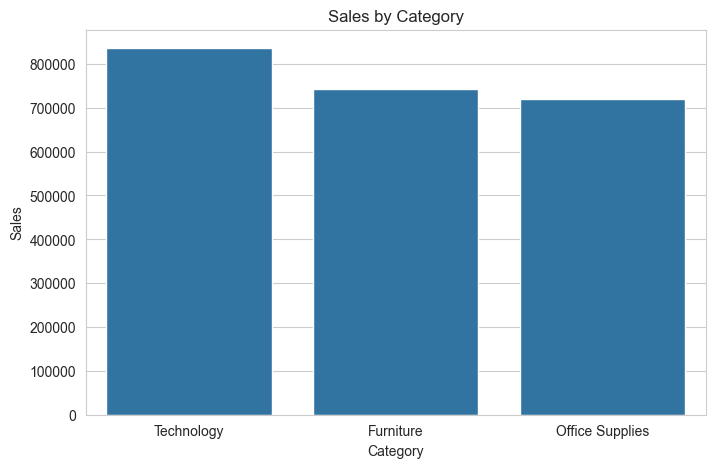

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Profit Analysis

In [14]:
profit_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

profit_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

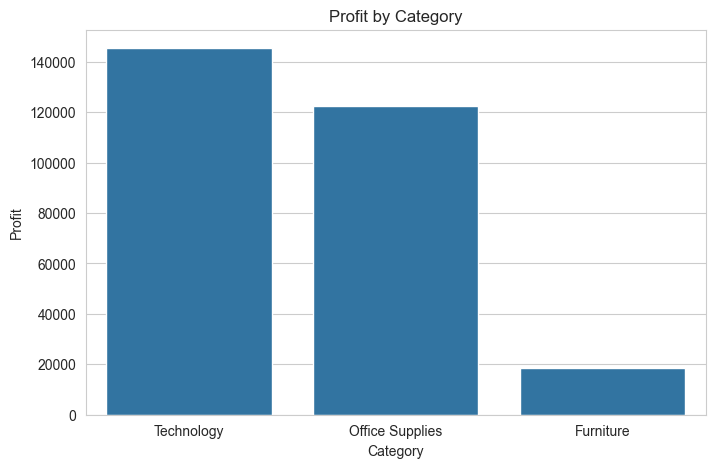

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_category.index,
    y=profit_category.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [16]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

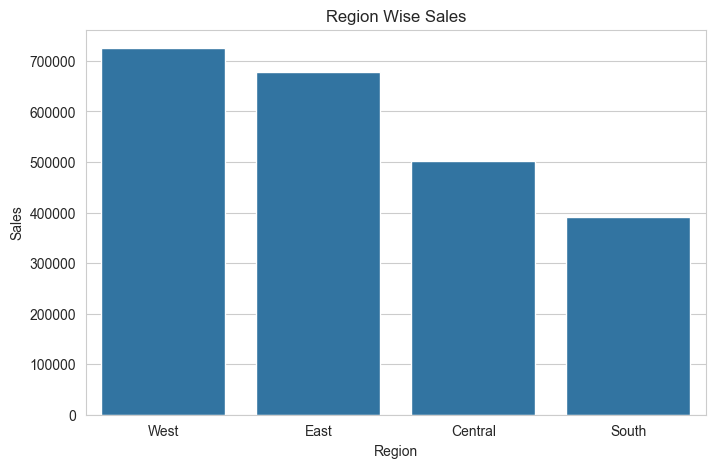

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Region Wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

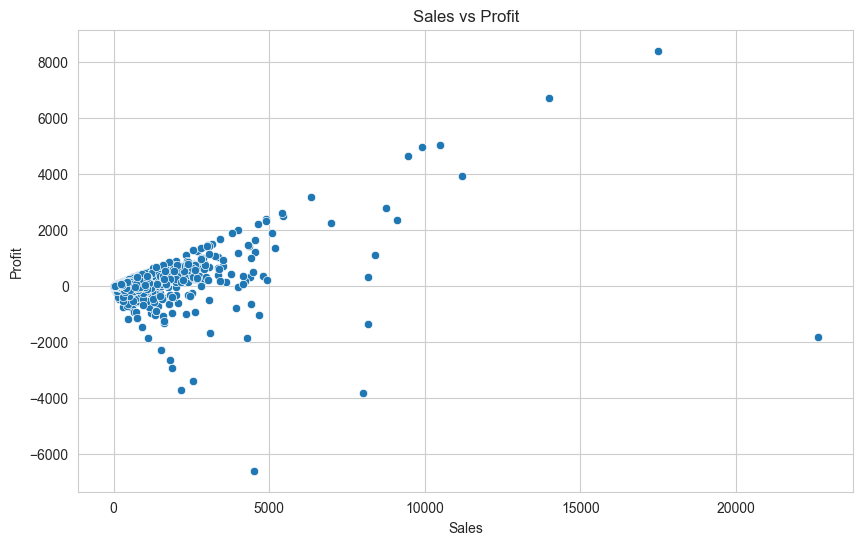

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Sales',
    y='Profit',
    data=df
)

plt.title("Sales vs Profit")
plt.show()

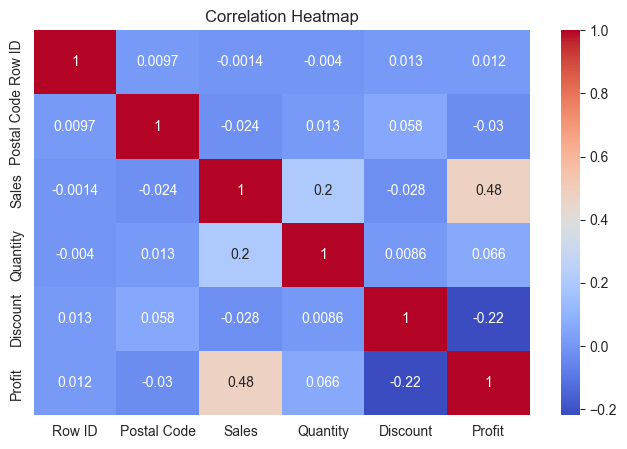

In [19]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
top_states = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

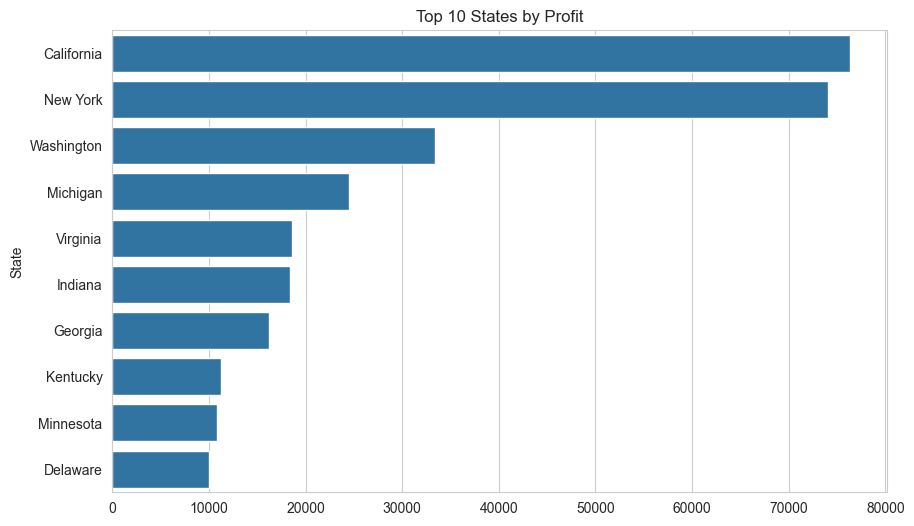

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Profit")

plt.show()

In [23]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

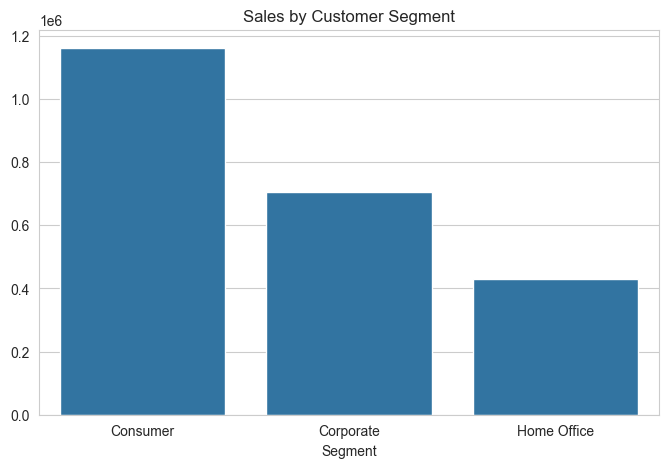

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")

plt.show()

Key Insights
1. Technology category generated the highest sales with approximately $836,154 in revenue, making it the most demanded product category.
2. Technology category also produced the highest profit of approximately $145,455, indicating strong profitability and customer demand.
3. Furniture category recorded high sales but relatively low profit, suggesting lower profit margins and possible impacts from discounts or operational costs.
4. Office Supplies showed balanced performance, contributing significantly to both sales and overall profit.
5. The West region generated the highest total sales, making it the best-performing region in terms of revenue generation.
6. The East region emerged as the second strongest market, contributing a substantial share of total sales.
7. California was the most profitable state, generating the highest profit among all states in the dataset.
8. New York also contributed significantly to overall profit, highlighting its importance as a major business market.
9. The Consumer segment generated the highest sales, indicating that individual customers form the largest customer base.
10. A positive relationship was observed between sales and profit, although some high-sales transactions generated lower profits, suggesting the influence of discounts and operational expenses.
11. The correlation analysis revealed meaningful relationships among numerical variables, helping identify factors affecting profitability and sales performance.
12. Business growth opportunities exist in lower-profit categories and regions, where strategic improvements could increase overall profitability.

Conclusion

This Exploratory Data Analysis (EDA) project analyzed the Superstore Sales Dataset to identify sales patterns, profitable categories, regional performance, and customer behavior.

The analysis revealed that Technology is the most successful category in terms of both sales and profit. The West region emerged as the top-performing region, while California generated the highest profit among all states. Consumer customers contributed the largest share of total revenue.

The findings provide valuable business insights that can support data-driven decision-making, improve profitability, and help organizations optimize their sales strategies.